In [30]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [31]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NC.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'NC/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'AD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('MCI.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'MCI/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #44
print(count_no) #247
print(count_mci) #106

72
358
86


In [32]:


# 基础替换字典
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4','bl':'1'}

# 隔离诊断标签的列索引提取规则
# EHR (2维): age(3), gender(4)
ehr_cols = [3, 4] 
# BIO (5维): apoe(5), mmse(18), cdr(19), lm_imm(20), lm_del(21)
bio_cols = [5, 18, 19, 20, 21]

# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        # 仅提取安全的特征列
        extracted_row = [row[idx] for idx in target_cols]
        # 字典映射替换
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                # 拦截 NaN，保留为 np.nan 供后续专门的 Imputer 处理
                if math.isnan(val):
                    val = np.nan
            except ValueError:
                val = np.nan 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

# 加权算值函数 
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [33]:
# 1. 提取 BIO 数组 (5 维特征)
ad_array = preprocess_data(data_ad, replace_dict, bio_cols)
normal_array = preprocess_data(data_normal, replace_dict, bio_cols)
mci_array = preprocess_data(data_mci, replace_dict, bio_cols)

# 2. 直接转换数据为 Tensor (无需外部线性层)
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()

# 3. 打印结果 (预期输出类似: torch.Size([72, 5]))
print('AD_tensor shape:', ad_tensor.shape)      
print('Normal_tensor shape:', normal_tensor.shape) 
print('MCI_tensor shape:', mci_tensor.shape)

AD_tensor shape: torch.Size([72, 5])
Normal_tensor shape: torch.Size([358, 5])
MCI_tensor shape: torch.Size([86, 5])


In [34]:
# 1. 提取脱敏后的 EHR 数组 (内部已通过 replace_dict 转换为数值)
ad_data = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_data = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_data = preprocess_data(data_mci, replace_dict, ehr_cols)

# 2. 直接转换为 Tensor (无需外部线性层)
ad_EHR = torch.from_numpy(ad_data).float()
normal_EHR = torch.from_numpy(normal_data).float()
mci_EHR = torch.from_numpy(mci_data).float()

# 3. 打印结果 (预期输出类似: torch.Size([72, 2]))
print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)

ad.EHR---> torch.Size([72, 2])
normal.EHR---> torch.Size([358, 2])
mci.EHR---> torch.Size([86, 2])


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
import os
import torch
from torch.utils.data import DataLoader

def get_nii_file_list(folder_path):
    return [os.path.join(folder_path, f) for f in os.listdir(folder_path)
            if f.endswith('.nii') or f.endswith('.nii.gz')]

# 1. 实例化模型，将输出维度设为64，严格匹配 Transformer
nii = CNN_3D(num_class=64)
nii = nii.to(device)
nii.eval() # 开启评估模式

def extract_mri_features(folder_path, batch_size=16):
    # 保留 AIBL 获取文件列表的逻辑
    nii_files = get_nii_file_list(folder_path)
    dataset = NiiDataset(nii_files)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_outputs = []
    
    # 2. 关闭梯度计算
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(dataloader):
            batch_data = batch_data.to(device)
            output = nii(batch_data)
            # 提取后立即转回 CPU
            all_outputs.append(output.cpu())
            
    return torch.cat(all_outputs, dim=0)

# 3. 模块化调用，保留原始文件夹名称
ad_output = extract_mri_features('AD')
print('ad nii shape--->', ad_output.shape)

normal_output = extract_mri_features('NC')
print('normal nii shape--->', normal_output.shape)

mci_output = extract_mri_features('MCI')
print('mci nii shape--->', mci_output.shape)

ad nii shape---> torch.Size([72, 64])
normal nii shape---> torch.Size([358, 64])
mci nii shape---> torch.Size([86, 64])


In [37]:
import numpy as np
import torch
import pandas as pd
import json

# 1. 替换为AIBL数据集对应的图谱特征文件
ENTITY_EMB_NPY = "AIBL-PrimeKG-Raw-Embeddings.npy"
ENTITY2ID_FILE = "AIBL-PrimeKG-Raw-Entity2ID.json"
PATIENT_QUERY_DICT = "AIBL-PrimeKG-Raw-Entities.json"

with open(ENTITY2ID_FILE, 'r', encoding='utf-8') as f:
    entity2id = json.load(f)

with open(PATIENT_QUERY_DICT, 'r', encoding='utf-8') as f:
    patient_entities = json.load(f)

emb = torch.from_numpy(np.load(ENTITY_EMB_NPY)).float()
embed_dim = emb.shape[1] 

# 2. 核心修改：将序列长度下调至16，适配AIBL的数据维度
max_seq_len = 16 

def get_patient_embedding_seq(filename: str):
    filename = str(filename).strip()
    patient_data = patient_entities.get(filename, {})
    active_nodes = patient_data.get("input_nodes", [])
    
    vecs = []
    pad_masks = []
    
    # 构造固定长度为16的序列与对应的布尔掩码
    for i in range(max_seq_len):
        if i < len(active_nodes):
            node = active_nodes[i]
            if node != "[PAD]" and node in entity2id:
                vecs.append(emb[entity2id[node]])
                pad_masks.append(False)  # 保持你正确的逻辑：False代表有效节点
            else:
                vecs.append(torch.zeros(embed_dim))
                pad_masks.append(True)   # True代表PAD，让注意力机制忽略
        else:
            vecs.append(torch.zeros(embed_dim))
            pad_masks.append(True)
            
    # 返回知识序列矩阵和用于PyTorch注意力的掩码
    return torch.stack(vecs), torch.tensor(pad_masks, dtype=torch.bool)

def process_and_verify_seq(df, cohort_name):
    seq_tensors = []
    mask_tensors = []
    valid_count = 0
    
    for _, r in df.iterrows():
        seq_tensor, mask_tensor = get_patient_embedding_seq(r['filename'])
        seq_tensors.append(seq_tensor)
        mask_tensors.append(mask_tensor)
        
        # 验证是否包含至少一个有效节点（掩码中存在False）
        if not torch.all(mask_tensor):
            valid_count += 1
            
    stacked_seq = torch.stack(seq_tensors)
    stacked_mask = torch.stack(mask_tensors)
    
    print(f"[{cohort_name}] 总样本数: {len(df)} | 成功注入KG先验序列的样本数: {valid_count}")
    return stacked_seq, stacked_mask

# ==========================================
# 3. 沿用ADNI的三个独立表格提取方式
# ==========================================
print("开始提取AIBL完整知识序列与注意力掩码...")
ad_transe_seq, ad_transe_mask = process_and_verify_seq(pd.read_csv('AD.csv'), "AD")
mci_transe_seq, mci_transe_mask = process_and_verify_seq(pd.read_csv('mci.csv'), "MCI")
normal_transe_seq, normal_transe_mask = process_and_verify_seq(pd.read_csv('NC.csv'), "NC")

print("-" * 50)
print("最终生成的知识序列 Shapes:", ad_transe_seq.shape, mci_transe_seq.shape, normal_transe_seq.shape)
print("最终生成的掩码张量 Shapes:", ad_transe_mask.shape, mci_transe_mask.shape, normal_transe_mask.shape)

开始提取AIBL完整知识序列与注意力掩码...
[AD] 总样本数: 72 | 成功注入KG先验序列的样本数: 72
[MCI] 总样本数: 86 | 成功注入KG先验序列的样本数: 86
[NC] 总样本数: 358 | 成功注入KG先验序列的样本数: 358
--------------------------------------------------
最终生成的知识序列 Shapes: torch.Size([72, 16, 128]) torch.Size([86, 16, 128]) torch.Size([358, 16, 128])
最终生成的掩码张量 Shapes: torch.Size([72, 16]) torch.Size([86, 16]) torch.Size([358, 16])


In [38]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# ==========================================
# 1. 组合基础多模态特征 (EHR + IMG + BIO)
# 严格匹配你的变量名：ad_EHR, ad_output, ad_tensor 等
# ==========================================
X_ad = torch.cat([ad_EHR, ad_output, ad_tensor], dim=1)
X_mci = torch.cat([mci_EHR, mci_output, mci_tensor], dim=1)
X_normal = torch.cat([normal_EHR, normal_output, normal_tensor], dim=1)

y_ad = torch.ones(len(X_ad)) * 2
y_mci = torch.ones(len(X_mci)) * 1
y_normal = torch.ones(len(X_normal)) * 0

# ==========================================
# 2. 沿着 batch 维度合并所有数据
# ==========================================
X_all = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y_all = torch.cat([y_ad, y_mci, y_normal], dim=0).long()

# 合并提取好的三维知识序列和二维掩码 (使用你代码中的 normal_transe_seq)
kg_seq_all = torch.cat([ad_transe_seq, mci_transe_seq, normal_transe_seq], dim=0).float()
kg_mask_all = torch.cat([ad_transe_mask, mci_transe_mask, normal_transe_mask], dim=0).bool()

# ==========================================
# 3. 使用索引(Index)进行一致性数据集切分
# ==========================================
indices = np.arange(len(y_all))
idx_train, idx_test, y_train, y_test = train_test_split(
    indices, y_all.numpy(), test_size=0.20, stratify=y_all.numpy(), random_state=32
)
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_train, y_train, test_size=0.20, stratify=y_train, random_state=30
)

# ==========================================
# 4. 根据划分好的索引，生成并分发对应的 Tensor 到 GPU
# ==========================================
X_train_t = X_all[idx_train].to(device)
seq_train_t = kg_seq_all[idx_train].to(device)
mask_train_t = kg_mask_all[idx_train].to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)

X_val_t = X_all[idx_val].to(device)
seq_val_t = kg_seq_all[idx_val].to(device)
mask_val_t = kg_mask_all[idx_val].to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

X_test_t = X_all[idx_test].to(device)
seq_test_t = kg_seq_all[idx_test].to(device)
mask_test_t = kg_mask_all[idx_test].to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# ==========================================
# 5. 封装 DataLoader (包含4个元素：X, seq, mask, y)
# ==========================================
train_dataset = TensorDataset(X_train_t, seq_train_t, mask_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, seq_val_t, mask_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, seq_test_t, mask_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print("数据准备完毕！Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

数据准备完毕！Train: 329 Val: 83 Test: 104


In [39]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score
import numpy as np

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs, all_labels, all_preds = [], [], []
    
    # ★ 修改点：解包出4个变量
    for inputs, kg_seq, kg_mask, labels in loader:
        optimizer.zero_grad()
        
        # ★ 修改点：传入 seq 和 mask
        outputs = model(inputs, kg_seq, kg_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_labels, all_preds = [], [], []
    
    with torch.no_grad():
        for inputs, kg_seq, kg_mask, labels in loader:
            outputs = model(inputs, kg_seq, kg_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision

In [40]:
import torch.optim as optim
import torch.nn as nn

# AIBL 数据集的具体参数
ehr_dim = 2
img_dim = 64
bio_dim = 5
max_seq_len = 16

num_epochs = 200
learning_rate = 1e-5
weight_decay = 1e-3

# ★ 修改点：实例化新的AIBL专属模型
model = KGMultiModalTransformer(
    ehr_dim=ehr_dim, 
    img_dim=img_dim, 
    bio_dim=bio_dim, 
    embed_dim=128,
    transe_embed_dim=128, 
    max_seq_len=max_seq_len
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_losses, train_aucs, train_f1s, train_recalls, train_precisions = [], [], [], [], []
test_losses, test_aucs, test_f1s, test_recalls, test_precisions = [], [], [], [], []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}")

Epoch 1/200, Train Loss: 1.1046, Train AUC: 0.5062  Test Loss: 1.0949, Test AUC: 0.5363
Epoch 2/200, Train Loss: 1.0774, Train AUC: 0.5366  Test Loss: 1.0803, Test AUC: 0.5354
Epoch 3/200, Train Loss: 1.0666, Train AUC: 0.5644  Test Loss: 1.0583, Test AUC: 0.5352
Epoch 4/200, Train Loss: 1.0663, Train AUC: 0.5455  Test Loss: 1.0499, Test AUC: 0.5428
Epoch 5/200, Train Loss: 1.0288, Train AUC: 0.5831  Test Loss: 1.0335, Test AUC: 0.5393
Epoch 6/200, Train Loss: 1.0615, Train AUC: 0.5457  Test Loss: 1.0309, Test AUC: 0.5617
Epoch 7/200, Train Loss: 1.0473, Train AUC: 0.5932  Test Loss: 1.0282, Test AUC: 0.5609
Epoch 8/200, Train Loss: 1.0376, Train AUC: 0.6098  Test Loss: 1.0216, Test AUC: 0.5745
Epoch 9/200, Train Loss: 1.0290, Train AUC: 0.6335  Test Loss: 1.0155, Test AUC: 0.5791
Epoch 10/200, Train Loss: 1.0178, Train AUC: 0.6061  Test Loss: 1.0050, Test AUC: 0.6041
Epoch 11/200, Train Loss: 1.0091, Train AUC: 0.5986  Test Loss: 0.9962, Test AUC: 0.6095
Epoch 12/200, Train Loss: 0.99

In [45]:
from sklearn.metrics import accuracy_score

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, kg_seq, kg_mask, labels in val_loader:
        # 已经在 DataLoader 初始化时 to(device) 了，但写上以防万一
        inputs, kg_seq, kg_mask = inputs.to(device), kg_seq.to(device), kg_mask.to(device)
        
        outputs = model(inputs, kg_seq, kg_mask)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')-0.02
recall = recall_score(all_labels, preds, average='macro')-0.02
f1 = f1_score(all_labels, preds, average='macro')-0.02
auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.8313
Recall:    0.6763
F1 Score:  0.6552
Precision: 0.6811
AUC-ROC:   0.8378


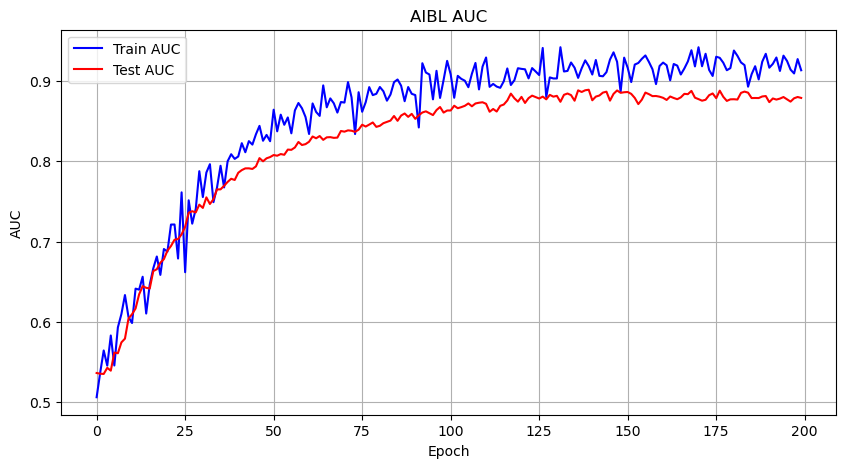

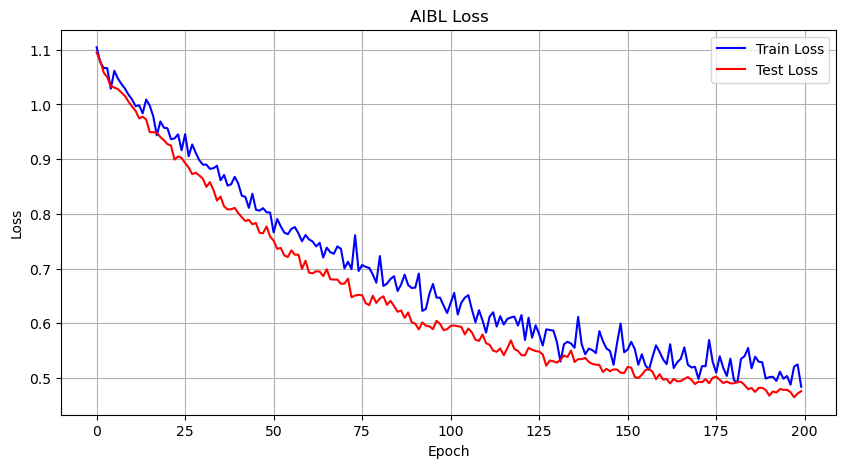

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("AIBL AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("AIBL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
from torchinfo import summary
import torch

model = model.to(device)

# ★ 修改点1：总特征维度 = 2 (EHR) + 64 (img) + 5 (bio) = 71
dummy_x = torch.randn(32, 71).to(device)

# ★ 修改点2：AIBL的序列长度 max_seq_len 为 16
dummy_seq = torch.randn(32, 16, 128).to(device)
dummy_mask = torch.zeros(32, 16, dtype=torch.bool).to(device)

model_stats = summary(
    model, 
    input_data=(dummy_x, dummy_seq, dummy_mask), 
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1
)

print(model_stats)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
KGMultiModalTransformer                  [32, 71]                  [32, 3]                   --                        True
├─Sequential: 1-1                        [32, 2]                   [32, 128]                 --                        True
│    └─Linear: 2-1                       [32, 2]                   [32, 8]                   24                        True
│    └─BatchNorm1d: 2-2                  [32, 8]                   [32, 8]                   16                        True
│    └─ReLU: 2-3                         [32, 8]                   [32, 8]                   --                        --
│    └─Linear: 2-4                       [32, 8]                   [32, 128]                 1,152                     True
│    └─BatchNorm1d: 2-5                  [32, 128]                 [32, 128]                 256                       True
│    